In [1]:
import numpy as np
from numpy.polynomial.legendre import Legendre
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from scipy import stats

from numpy.random import uniform as unif

import os 
import sys

sys.path.append("./../../")
from utils import *

In [2]:
def sample_TOS(df, covs, coefs, probs):
    df["Y0"] = df.apply(lambda row: sample_bernoulli(row, covs, coefs["Y0"], probs["Y0"]), axis=1)
    df["Y1"] = df.apply(lambda row: sample_bernoulli(row, covs, coefs["Y1"], probs["Y1"]), axis=1)
    df["A"] = df.apply(lambda row: sample_bernoulli(row, covs, coefs["A"], probs["A"]), axis=1)
    df["Y"] = df["A"] * df["Y1"] + (1 - df["A"]) * df["Y0"]
    df["S"] = df.apply(lambda row: sample_bernoulli(row, covs, coefs["S"], probs["S"]), axis=1)


def fit_model(df, covs, target, model, filter_fit='index==index'): 
    model.fit(df.query(filter_fit)[covs], df.query(filter_fit)[target])

    return model


def fit_all_models(df, covs, models={"S": LogisticRegression(), 
                                     "A": LogisticRegression(), 
                                     "Y": LogisticRegression()}):
    
    PS_model = fit_model(df, covs, "S", models["S"], filter_fit='index==index')
    PA_model = fit_model(df, covs, "A", models["A"], filter_fit='S==1')
    PY0_model = fit_model(df, covs, "Y", models["Y"], filter_fit='S==1 & A==0')
    PY1_model = fit_model(df, covs, "Y", models["Y"], filter_fit='S==1 & A==1')
    
    return {"S": PS_model, "A": PA_model, "Y0": PY0_model, "Y1": PY1_model}


def log_model_preds(df, covs, targets, models):
    for target in targets:
        df[f"hat_P({target}=1)"] = models[target].predict_proba(df[covs])[:,-1]
        df[f"SE_{target}"] = (df[target] - df[f"hat_P({target}=1)"]) ** 2


def psi_R(row, R):
    if row["R"] != R or row["S"] == 0:
        return 0
    else:
        a_ind = row["A"]
        p_r1, p_a1, p_s1 = row["hat_P(R=1)"], row["hat_P(A=1)"], row["hat_P(S=1)"]
        y, mu0, mu1 = row["Y"], row["hat_P(Y0=1)"], row["hat_P(Y1=1)"]

        term_1 = mu1 - mu0
        term_2 = a_ind * (y - mu1) / p_a1
        term_3 = (1 - a_ind) * (y - mu0) / (1 - p_a1)

        p_r = R * p_r1 + (1 - R) * (1 - p_r1)

        return (term_1 + term_2 - term_3) / (p_r * p_s1)
    

def calc_psi(df):
    df["psi0"] = df.apply(lambda row: psi_R(row, 0), axis=1)
    df["psi1"] = df.apply(lambda row: psi_R(row, 1), axis=1)
    df["psi"] = df["psi1"] - df["psi0"]


def merge_df(df_rct, df_obs, covs, pr_model=LogisticRegression()):
    df = pd.concat([df_rct, df_obs]).reset_index(drop=True)
    fit_pr_model = fit_model(df, covs, "R", pr_model)

    df["hat_P(R=1)"] = fit_pr_model.predict_proba(df[covs])[:,-1]
    df["SE_R"] = (df["R"] - df[f"hat_P(R=1)"]) ** 2

    calc_psi(df)

    return df, fit_pr_model


def init_df(n, d, r):
    X_rct = legendre_mat(unif(-1, 1, n), d)
    U_rct = legendre_mat(unif(-1, 1, n), d)

    meas_covs = [f"X{i + 1}" for i in range(d)]
    unmeas_covs = [f"U{i + 1}" for i in range(d)]

    df = pd.DataFrame({**{'R': r},
                        **{cov: X_rct[:,i] for i, cov in enumerate(meas_covs)},
                        **{u_cov: U_rct[:,i] for i, u_cov in enumerate(unmeas_covs)}})
    
    return df

In [3]:
np.random.seed(42)

n_rct = 1000
n_obs = 5000
n_obs_val = 6000
d = 3

meas_covs = [f"X{i + 1}" for i in range(d)]
unmeas_covs = [f"U{i + 1}" for i in range(d)]
all_covs = meas_covs + unmeas_covs

K = 50
biases = {"avg": [], "X<0": [], "X>0": []}
covariances = {"SE_Y0": [], "SE_Y1": [], "SE_A": [], "SE_S": [], "SE_R": []}

for sim_idx in range(K):
    df_rct = init_df(n_rct, d, r=1)
    df_obs = init_df(n_obs, d, r=0)
    df_obs_val = init_df(n_obs_val, d, r=0)

    rct_legendre_coefs = {"Y0": unif(-1, 1, 2 * d + 1),
                        "Y1": unif(-1, 1, 2 * d + 1),
                        "A": None,
                        "S": None,}

    obs_legendre_coefs = {"Y0": rct_legendre_coefs["Y0"],
                        "Y1": rct_legendre_coefs["Y1"],
                        "A": unif(-1, 1, 2 * d + 1),
                        "S": None,}

    # np.concatenate((unif(-.5, .5, 1), unif(-1, 1, 3), unif(-3, 3, 3)))

    random_probs = {"Y0": 0.5, "Y1": 0.5, "A": 0.5, "S": 0.95}

    # generate data and fit estimators

    sample_TOS(df_rct, all_covs, rct_legendre_coefs, random_probs)
    rct_models = fit_all_models(df_rct, meas_covs)
    log_model_preds(df_rct, meas_covs, ["S", "A", "Y0", "Y1"], rct_models)

    sample_TOS(df_obs, all_covs, obs_legendre_coefs, random_probs)
    obs_models = fit_all_models(df_obs, meas_covs)
    log_model_preds(df_obs, meas_covs, ["S", "A", "Y0", "Y1"], obs_models)

    df_merged, pr_model = merge_df(df_rct, df_obs, meas_covs)

    # K1 = rbf_kernel(df_merged[meas_covs])
    # df_merged['w(X)'] = K1 @ df_merged['psi']

    sample_TOS(df_obs_val, all_covs, obs_legendre_coefs, random_probs)
    log_model_preds(df_obs_val, meas_covs, ["S", "A", "Y0", "Y1"], obs_models)
    df_obs_val["hat_P(R=1)"] = pr_model.predict_proba(df_obs_val[meas_covs])[:,-1]
    df_obs_val["SE_R"] = (df_obs_val["R"] - df_obs_val[f"hat_P(R=1)"]) ** 2

    K2 = rbf_kernel_two_matrices(df_obs_val[meas_covs], df_merged[meas_covs])
    df_obs_val['w(X)'] = K2 @ df_merged['psi']

    for key in covariances:
        m, p, _, _ = pearsonr_ci(df_obs_val, "w(X)", key)
        covariances[key].append((m,p))

(array([49.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,
         0.,  0.,  0.,  0.,  0.,  0.,  0.,  0.,  1.]),
 array([0.        , 0.00372499, 0.00744999, 0.01117498, 0.01489997,
        0.01862497, 0.02234996, 0.02607496, 0.02979995, 0.03352494,
        0.03724994, 0.04097493, 0.04469992, 0.04842492, 0.05214991,
        0.05587491, 0.0595999 , 0.06332489, 0.06704989, 0.07077488,
        0.07449987, 0.07822487, 0.08194986, 0.08567485, 0.08939985,
        0.09312484, 0.09684984, 0.10057483, 0.10429982, 0.10802482,
        0.11174981, 0.1154

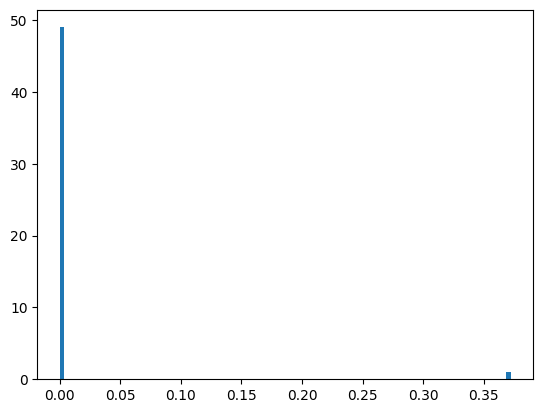

In [24]:
plt.hist(np.array(covariances["SE_R"])[:,1], bins=100)

In [ ]:
X = np.random.rand(5, 3)  
Y = np.random.rand(4, 3)
K = rbf_kernel_two_matrices(X, Y)

print("Kernel matrix between X and Y:")
print(K)